In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_kddcup99
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


In [3]:
print("Dataset download ho raha hai... (1-2 min)")
data = fetch_kddcup99(subset=None, shuffle=True, random_state=42, percent10=True)

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(f"✅ Dataset loaded! Shape: {df.shape}")
print("\nAttack types:")
print(df['target'].value_counts())

Dataset download ho raha hai... (1-2 min)
✅ Dataset loaded! Shape: (494021, 42)

Attack types:
target
b'smurf.'              280790
b'neptune.'            107201
b'normal.'              97278
b'back.'                 2203
b'satan.'                1589
b'ipsweep.'              1247
b'portsweep.'            1040
b'warezclient.'          1020
b'teardrop.'              979
b'pod.'                   264
b'nmap.'                  231
b'guess_passwd.'           53
b'buffer_overflow.'        30
b'land.'                   21
b'warezmaster.'            20
b'imap.'                   12
b'rootkit.'                10
b'loadmodule.'              9
b'ftp_write.'               8
b'multihop.'                7
b'phf.'                     4
b'perl.'                    3
b'spy.'                     2
Name: count, dtype: int64


In [4]:
# Binary classification: normal vs attack
df['target'] = df['target'].apply(lambda x: x.decode('utf-8').strip('.'))
df['label'] = df['target'].apply(lambda x: 0 if x == 'normal' else 1)

print(f"Normal traffic: {(df['label']==0).sum()}")
print(f"Attack traffic: {(df['label']==1).sum()}")
print(f"\nAttack %: {df['label'].mean()*100:.1f}%")

Normal traffic: 97278
Attack traffic: 396743

Attack %: 80.3%


In [5]:
# Encode categorical columns
cat_cols = ['protocol_type', 'service', 'flag']
le = LabelEncoder()

for col in cat_cols:
    df[col] = df[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
    df[col] = le.fit_transform(df[col])

# Features aur target alag karo
X = df.drop(['target', 'label'], axis=1)
y = df['label']

print(f"✅ Features shape: {X.shape}")
print(f"Feature list:\n{list(X.columns)}")

✅ Features shape: (494021, 41)
Feature list:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale karo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Train size: {X_train.shape}")
print(f"✅ Test size:  {X_test.shape}")

✅ Train size: (395216, 41)
✅ Test size:  (98805, 41)


In [7]:
print("⏳ Random Forest train ho raha hai...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f"✅ Random Forest Accuracy: {rf_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Attack']))

⏳ Random Forest train ho raha hai...
✅ Random Forest Accuracy: 99.98%

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     19456
      Attack       1.00      1.00      1.00     79349

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805



In [8]:
print("⏳ XGBoost train ho raha hai...")
xgb = XGBClassifier(n_estimators=100, random_state=42, 
                     use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print(f"✅ XGBoost Accuracy: {xgb_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Normal', 'Attack']))

⏳ XGBoost train ho raha hai...
✅ XGBoost Accuracy: 99.98%

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     19456
      Attack       1.00      1.00      1.00     79349

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805



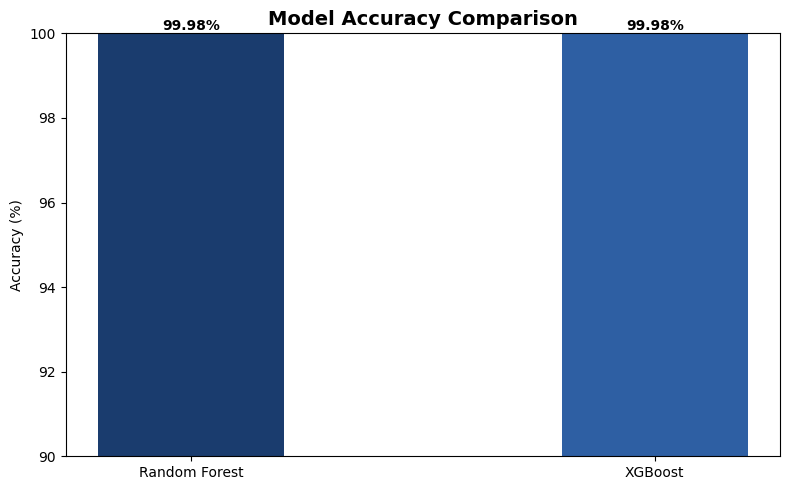

✅ Plot saved!


In [9]:
models = ['Random Forest', 'XGBoost']
accuracies = [rf_acc*100, xgb_acc*100]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies, color=['#1A3C6E', '#2E5FA3'], width=0.4)
plt.ylim(90, 100)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{acc:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../models/accuracy_comparison.png', dpi=150)
plt.show()
print("✅ Plot saved!")

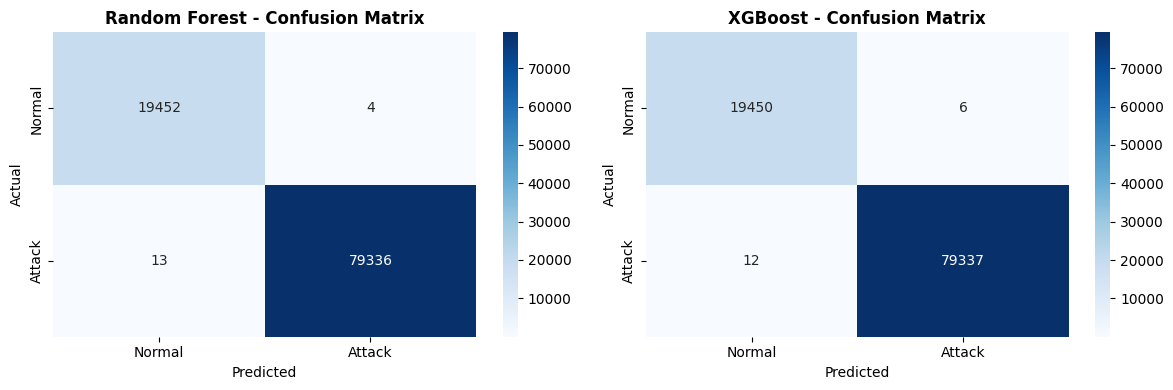

✅ Confusion matrix saved!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, y_pred) in zip(axes, [('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'])
    ax.set_title(f'{name} - Confusion Matrix', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

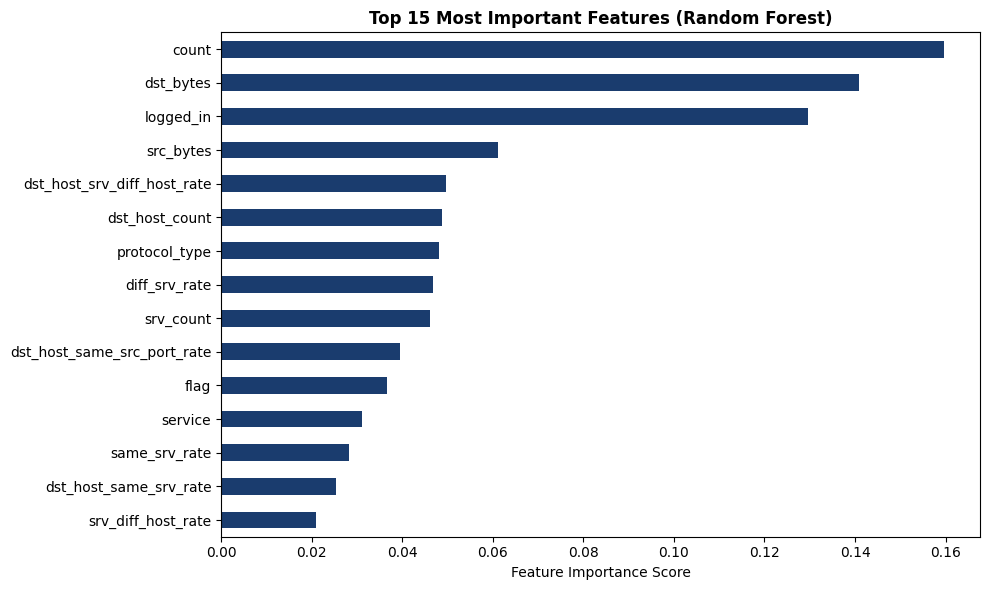

✅ Feature importance saved!


In [11]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
top15 = feat_imp.nlargest(15)

plt.figure(figsize=(10, 6))
top15.sort_values().plot(kind='barh', color='#1A3C6E')
plt.title('Top 15 Most Important Features (Random Forest)', fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('../models/feature_importance.png', dpi=150)
plt.show()
print("✅ Feature importance saved!")

In [12]:
import joblib

joblib.dump(rf, '../models/random_forest_ids.pkl')
joblib.dump(xgb, '../models/xgboost_ids.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("✅ Models saved!")
print("\n📊 FINAL RESULTS SUMMARY:")
print(f"Random Forest Accuracy : {rf_acc*100:.2f}%")
print(f"XGBoost Accuracy       : {xgb_acc*100:.2f}%")

✅ Models saved!

📊 FINAL RESULTS SUMMARY:
Random Forest Accuracy : 99.98%
XGBoost Accuracy       : 99.98%


In [13]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("⏳ 5-Fold Cross Validation chal raha hai... (5-10 min lagenge)")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest pe
rf_cv_scores = cross_val_score(rf, X_train_scaled, y_train, 
                                cv=cv, scoring='accuracy', n_jobs=-1)

print(f"\nRandom Forest CV Scores: {rf_cv_scores}")
print(f"Mean: {rf_cv_scores.mean()*100:.2f}%")
print(f"Std Dev: {rf_cv_scores.std()*100:.4f}%")
print("\nAgar std dev < 0.5% hai toh model consistent hai ✅")
print("Agar mean CV ~ test accuracy hai toh overfitting nahi hai ✅")

⏳ 5-Fold Cross Validation chal raha hai... (5-10 min lagenge)

Random Forest CV Scores: [0.99987349 0.99973432 0.99982288 0.99981023 0.99988614]
Mean: 99.98%
Std Dev: 0.0054%

Agar std dev < 0.5% hai toh model consistent hai ✅
Agar mean CV ~ test accuracy hai toh overfitting nahi hai ✅


In [14]:
from sklearn.metrics import classification_report

print("=== RANDOM FOREST - Detailed Report ===")
print(classification_report(y_test, y_pred_rf, 
      target_names=['Normal', 'Attack'], digits=4))

# Precision/Recall alag alag dekhna zaroori hai
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Negatives  (Normal correctly identified): {tn}")
print(f"False Positives (Normal wrongly flagged):       {fp}  ← Type 1 Error")
print(f"False Negatives (Attack missed!):               {fn}  ← Type 2 Error ⚠️")
print(f"True Positives  (Attack correctly caught):      {tp}")
print(f"\nFalse Negative Rate: {fn/(fn+tp)*100:.3f}% (Attacks jo miss hue)")

=== RANDOM FOREST - Detailed Report ===
              precision    recall  f1-score   support

      Normal     0.9993    0.9998    0.9996     19456
      Attack     0.9999    0.9998    0.9999     79349

    accuracy                         0.9998     98805
   macro avg     0.9996    0.9998    0.9997     98805
weighted avg     0.9998    0.9998    0.9998     98805


True Negatives  (Normal correctly identified): 19452
False Positives (Normal wrongly flagged):       4  ← Type 1 Error
False Negatives (Attack missed!):               13  ← Type 2 Error ⚠️
True Positives  (Attack correctly caught):      79336

False Negative Rate: 0.016% (Attacks jo miss hue)


ROC AUC Score: 1.0000
(1.0 = perfect, 0.5 = random guessing)


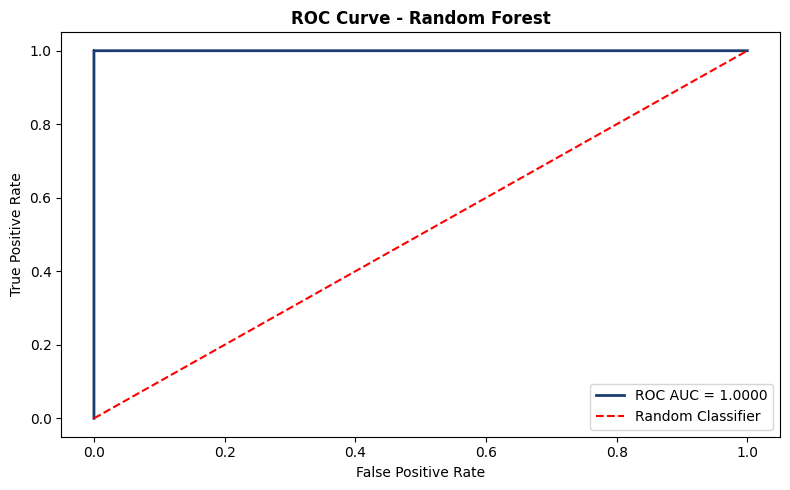

In [15]:
from sklearn.metrics import roc_auc_score, roc_curve

rf_proba = rf.predict_proba(X_test_scaled)[:, 1]
auc_score = roc_auc_score(y_test, rf_proba)
print(f"ROC AUC Score: {auc_score:.4f}")
print("(1.0 = perfect, 0.5 = random guessing)")

fpr, tpr, thresholds = roc_curve(y_test, rf_proba)
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='#1A3C6E', linewidth=2, label=f'ROC AUC = {auc_score:.4f}')
plt.plot([0,1], [0,1], 'r--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../models/roc_curve.png', dpi=150)
plt.show()

In [16]:
# Load UNSW dataset
train_unsw = pd.read_csv('../data/UNSW_NB15_training-set.csv')
test_unsw = pd.read_csv('../data/UNSW_NB15_testing-set.csv')

print("Train shape:", train_unsw.shape)
print("Test shape:", test_unsw.shape)
print("\nColumns:", list(train_unsw.columns))
print("\nLabel distribution (train):")
print(train_unsw['label'].value_counts())

Train shape: (175341, 45)
Test shape: (82332, 45)

Columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

Label distribution (train):
label
1    119341
0     56000
Name: count, dtype: int64


In [17]:
# UNSW mein categorical columns alag hain
cat_cols_unsw = ['proto', 'service', 'state']

df_unsw_test = test_unsw.copy()

# Categorical encode karo
le2 = LabelEncoder()
for col in cat_cols_unsw:
    df_unsw_test[col] = le2.fit_transform(df_unsw_test[col].astype(str))

# Label alag karo
y_unsw = df_unsw_test['label']

# Drop non-numeric / irrelevant columns
drop_cols = ['label', 'attack_cat', 'id'] 
X_unsw = df_unsw_test.drop([c for c in drop_cols if c in df_unsw_test.columns], axis=1)

print(f"UNSW Features: {X_unsw.shape[1]}")
print(f"KDD Features:  {X_train.shape[1]}")
print(f"\nUNSW Columns:\n{list(X_unsw.columns)}")

UNSW Features: 42
KDD Features:  41

UNSW Columns:
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']


In [18]:
# KDD aur UNSW ke common features dhundo
kdd_features = set(X_train.columns)
unsw_features = set(X_unsw.columns)

common = kdd_features.intersection(unsw_features)
print(f"Common features: {len(common)}")
print(sorted(common))

if len(common) < 5:
    print("\n⚠️ Bahut kam common features hain!")
    print("Direct transfer possible nahi — UNSW pe fresh model train karna padega")
else:
    print("\n✅ Enough common features — cross test possible!")
    X_unsw_aligned = X_unsw[sorted(common)]
    X_kdd_aligned = X_train[sorted(common)]

Common features: 1
['service']

⚠️ Bahut kam common features hain!
Direct transfer possible nahi — UNSW pe fresh model train karna padega


In [19]:
# Fresh start on UNSW
df_train_unsw = train_unsw.copy()
df_test_unsw = test_unsw.copy()

# Categorical encode
cat_cols_unsw = ['proto', 'service', 'state']
le_unsw = {}

for col in cat_cols_unsw:
    le_unsw[col] = LabelEncoder()
    df_train_unsw[col] = le_unsw[col].fit_transform(df_train_unsw[col].astype(str))
    # Test mein unseen labels handle karo
    df_test_unsw[col] = df_test_unsw[col].astype(str).apply(
        lambda x: x if x in le_unsw[col].classes_ else 'unknown'
    )
    # unknown ko 0 de do
    le_unsw[col].classes_ = np.append(le_unsw[col].classes_, 'unknown')
    df_test_unsw[col] = le_unsw[col].transform(df_test_unsw[col])

# Drop irrelevant columns
drop_cols = ['label', 'attack_cat', 'id']
X_train_unsw = df_train_unsw.drop([c for c in drop_cols if c in df_train_unsw.columns], axis=1)
y_train_unsw = df_train_unsw['label']

X_test_unsw = df_test_unsw.drop([c for c in drop_cols if c in df_test_unsw.columns], axis=1)
y_test_unsw = df_test_unsw['label']

# Scale
scaler_unsw = StandardScaler()
X_train_unsw_scaled = scaler_unsw.fit_transform(X_train_unsw)
X_test_unsw_scaled = scaler_unsw.transform(X_test_unsw)

print(f"✅ Train: {X_train_unsw.shape}")
print(f"✅ Test:  {X_test_unsw.shape}")
print(f"\nLabel distribution:")
print(y_train_unsw.value_counts())

✅ Train: (175341, 42)
✅ Test:  (82332, 42)

Label distribution:
label
1    119341
0     56000
Name: count, dtype: int64


In [21]:
print("⏳ Random Forest on UNSW-NB15...")
rf_unsw = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_unsw.fit(X_train_unsw_scaled, y_train_unsw)

y_pred_unsw = rf_unsw.predict(X_test_unsw_scaled)
acc_unsw = accuracy_score(y_test_unsw, y_pred_unsw)

print(f"\n✅ UNSW-NB15 Accuracy: {acc_unsw*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test_unsw, y_pred_unsw,
      target_names=['Normal', 'Attack'], digits=4))

⏳ Random Forest on UNSW-NB15...

✅ UNSW-NB15 Accuracy: 87.33%

Detailed Report:
              precision    recall  f1-score   support

      Normal     0.9762    0.7360    0.8392     37000
      Attack     0.8205    0.9854    0.8954     45332

    accuracy                         0.8733     82332
   macro avg     0.8984    0.8607    0.8673     82332
weighted avg     0.8905    0.8733    0.8702     82332



In [23]:
import joblib
import numpy as np

# Naya LabelEncoder fit karo training data pe
le_dict = {}
cat_cols = ['protocol_type', 'service', 'flag']

for col in cat_cols:
    le_dict[col] = LabelEncoder()
    # Original df pe fit karo (poora training data)
    le_dict[col].fit(df[col].astype(str))
    print(f"{col} classes: {list(le_dict[col].classes_[:5])}...")

print("\n✅ Encoders ready!")

def predict_connection(features_dict):
    input_df = pd.DataFrame([features_dict])
    
    for col in cat_cols:
        if col in input_df.columns:
            val = input_df[col].astype(str)
            # Unseen label handle karo
            known = set(le_dict[col].classes_)
            input_df[col] = val.apply(
                lambda x: x if x in known else le_dict[col].classes_[0]
            )
            input_df[col] = le_dict[col].transform(input_df[col])
    
    scaled = scaler.transform(input_df)
    pred = rf.predict(scaled)[0]
    prob = rf.predict_proba(scaled)[0]
    
    return {
        "prediction": "🚨 ATTACK" if pred == 1 else "✅ NORMAL",
        "confidence": f"{max(prob)*100:.2f}%",
        "attack_probability": f"{prob[1]*100:.2f}%"
    }

# Test karo
normal_connection = {
    'duration': 0, 'protocol_type': 'tcp', 'service': 'http',
    'flag': 'SF', 'src_bytes': 232, 'dst_bytes': 8153,
    'land': 0, 'wrong_fragment': 0, 'urgent': 0, 'hot': 0,
    'num_failed_logins': 0, 'logged_in': 1, 'num_compromised': 0,
    'root_shell': 0, 'su_attempted': 0, 'num_root': 0,
    'num_file_creations': 0, 'num_shells': 0, 'num_access_files': 0,
    'num_outbound_cmds': 0, 'is_host_login': 0, 'is_guest_login': 0,
    'count': 8, 'srv_count': 8, 'serror_rate': 0.0,
    'srv_serror_rate': 0.0, 'rerror_rate': 0.0, 'srv_rerror_rate': 0.0,
    'same_srv_rate': 1.0, 'diff_srv_rate': 0.0,
    'srv_diff_host_rate': 0.0, 'dst_host_count': 255,
    'dst_host_srv_count': 255, 'dst_host_same_srv_rate': 1.0,
    'dst_host_diff_srv_rate': 0.0, 'dst_host_same_src_port_rate': 0.01,
    'dst_host_srv_diff_host_rate': 0.0, 'dst_host_serror_rate': 0.0,
    'dst_host_srv_serror_rate': 0.0, 'dst_host_rerror_rate': 0.0,
    'dst_host_srv_rerror_rate': 0.0
}

attack_connection = {**normal_connection,
    'protocol_type': 'icmp', 'service': 'ecr_i',
    'flag': 'SF', 'src_bytes': 1032, 'dst_bytes': 0,
    'count': 511, 'srv_count': 511,
    'same_srv_rate': 1.0, 'logged_in': 0
}

print("\nTesting Normal Connection:")
print(predict_connection(normal_connection))

print("\nTesting Attack Connection:")
print(predict_connection(attack_connection))

protocol_type classes: ['0', '1', '2']...
service classes: ['0', '1', '10', '11', '12']...
flag classes: ['0', '1', '10', '2', '3']...

✅ Encoders ready!

Testing Normal Connection:
{'prediction': '✅ NORMAL', 'confidence': '82.00%', 'attack_probability': '18.00%'}

Testing Attack Connection:
{'prediction': '🚨 ATTACK', 'confidence': '79.00%', 'attack_probability': '79.00%'}
